<a href="https://colab.research.google.com/github/Faizaa01/Machine_Learning_Fundamentals/blob/main/AI_ML_Assignment_3_Module_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [2]:
# TODO: Import all necessary libraries here
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVR, SVC
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [3]:
# TODO: Load regression dataset
import kagglehub
import os

path = kagglehub.dataset_download("mirichoi0218/insurance")
print("Path to dataset files:", path)
os.listdir(path)

df = pd.read_csv(os.path.join(path, "insurance.csv"))
print("Shape: ", df.shape)
print("Columns: ", df.columns)
print(df.head())


Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance
Shape:  (1338, 7)
Columns:  Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


***Explanation:*** The target variable is charges, which represents the medical insurance cost to be predicted. Since the target variable is continuous, this is a supervised regression problem.

In [4]:
print(df.info(),"\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None 

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010 



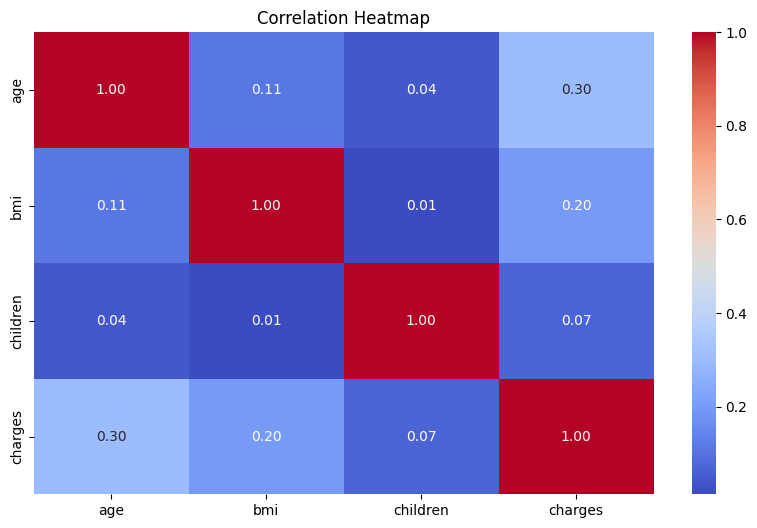

In [5]:
# TODO: Perform EDA
print(df.describe(),"\n")

num_for_corr = ["age", "bmi", "children", "charges"]
plt.figure(figsize=(10,6))
sns.heatmap(df[num_for_corr].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


***Interpretation:***
Charges has the highest correlation with age (0.30), meaning older people tend to have higher insurance costs. BMI also shows a moderate positive correlation with charges (0.20), so higher BMI slightly increases charges. Children has a very weak correlation with charges (0.07), meaning number of children doesn't strongly affect insurance cost.


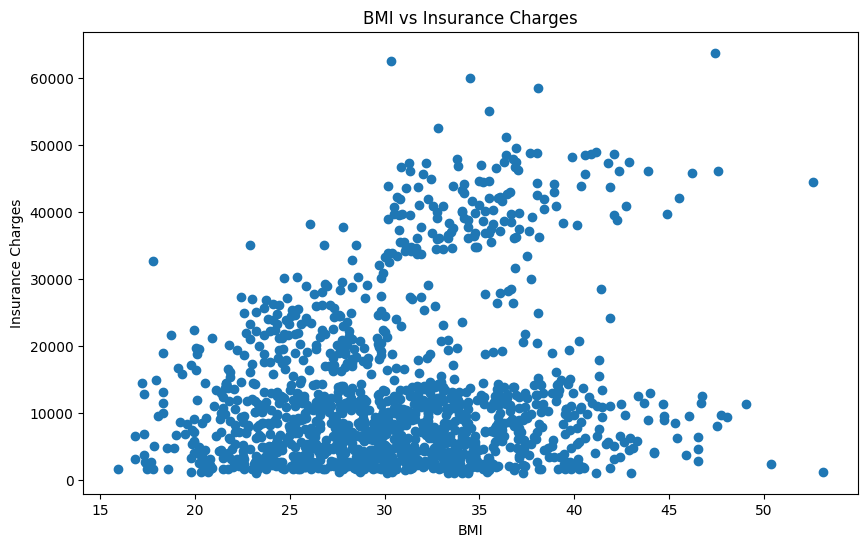

In [6]:
plt.figure(figsize=(10,6))
plt.scatter(df["bmi"], df["charges"])
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Insurance Charges")
plt.show()

***Interpretation:***



## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [7]:
# TODO: Prepare features
df_enc = df.copy()
cat_features = ["sex", "smoker", "region"]

df_enc = pd.get_dummies(
    df_enc,
    columns=cat_features,
    drop_first=True,
    dtype=int
)

X = df_enc.drop("charges", axis=1)
y = df_enc["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The categorical features (sex, smoker, region) were one-hot encoded to convert them into numeric form.

The dataset was split into training and testing sets (80:20) with random_state=42 to ensure reproducibility.

Feature scaling was applied using StandardScaler to normalize numeric values, which helps models sensitive to feature magnitude perform better.

## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [8]:
# TODO: Multiple Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

def reg_metrics(y_true ,y_pred, label='Model'):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)

  print(f"\n{label} Metrics:")
  print("Mean Absolute Error (MAE):", mae)
  print("Root Mean Squared Error (RMSE):", rmse)
  print("R squared (R²):", r2)

reg_metrics(y_train, y_train_pred, 'Linear Regression(Train)')
reg_metrics(y_test, y_test_pred, 'Linear Regression(Test)')



Linear Regression(Train) Metrics:
Mean Absolute Error (MAE): 4208.234572492226
Root Mean Squared Error (RMSE): 6105.545160099848
R squared (R²): 0.7417255854683333

Linear Regression(Test) Metrics:
Mean Absolute Error (MAE): 4181.194473753651
Root Mean Squared Error (RMSE): 5796.284659276274
R squared (R²): 0.7835929767120722


## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


In [9]:
# TODO: Polynomial Regression
model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lin_reg', LinearRegression())
])

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

def reg_metrics(y_true, y_pred, label='Model'):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{label} Metrics:")
    print("Mean Absolute Error (MAE):", mae)
    print("Root Mean Squared Error (RMSE):", rmse)
    print("R squared (R²):", r2)

reg_metrics(y_train, y_train_pred, 'Polynomial Regression(Train)')
reg_metrics(y_test, y_test_pred, 'Polynomial Regression(Test)')


Polynomial Regression(Train) Metrics:
Mean Absolute Error (MAE): 2892.1498400967935
Root Mean Squared Error (RMSE): 4778.187802539188
R squared (R²): 0.8418173231535121

Polynomial Regression(Test) Metrics:
Mean Absolute Error (MAE): 2729.500133639456
Root Mean Squared Error (RMSE): 4551.132385233192
R squared (R²): 0.8665830903164841


***Comparison:*** The polynomial regression performs better than linear regression, with lower MAE and RMSE and higher R² on both train and test sets. This shows it captures non-linear relationships in the data, giving more accurate predictions for insurance charges.

## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [10]:
# TODO: Support Vector Regression
scaler_svr = StandardScaler()
X_train_scaled = scaler_svr.fit_transform(X_train)
X_test_scaled = scaler_svr.transform(X_test)

svr_model = SVR(kernel='rbf', C=10.0, epsilon=0.1, gamma='scale')
svr_model.fit(X_train_scaled, y_train)

y_train_pred = svr_model.predict(X_train_scaled)
y_test_pred = svr_model.predict(X_test_scaled)

mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
mse_svr = mean_squared_error(y_test, y_test_pred)
r2_svr = r2_score(y_test, y_test_pred)


print("SVR (Train) Metrics:")
print("MSE:", mse_train)
print("R²:", r2_train)

print("\nSVR (Test) Metrics:")
print("Mean Squared Error (MSE):", mse_svr)
print("R² Score:", r2_svr)


SVR (Train) Metrics:
MSE: 152785910.17384472
R²: -0.05856077140925531

SVR (Test) Metrics:
Mean Squared Error (MSE): 160399196.14821088
R² Score: -0.03317556676274891


SVR performed very poorly on this dataset, with negative R² and extremely high MSE, meaning it fails to predict insurance charges accurately. It underfits the data and is much worse than the other models.

***Justification:*** The RBF kernel is chosen because it can model non-linear relationships in the data. Features like age, BMI, and smoking have complex interactions affecting insurance charges, so RBF allows the SVR to fit these patterns better than a linear kernel.

## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


In [11]:
# TODO: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

def reg_metrics(y_true, y_pred, label='Model'):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{label} Metrics:")
    print("Mean Absolute Error (MAE):", mae)
    print("Root Mean Squared Error (RMSE):", rmse)
    print("R squared (R²):", r2)

reg_metrics(y_train, y_train_pred, 'Random Forest (Train)')
reg_metrics(y_test, y_test_pred, 'Random Forest (Test)')


Random Forest (Train) Metrics:
Mean Absolute Error (MAE): 1060.7693980899546
Root Mean Squared Error (RMSE): 1931.370165235786
R squared (R²): 0.9741557742042207

Random Forest (Test) Metrics:
Mean Absolute Error (MAE): 2543.9758251029275
Root Mean Squared Error (RMSE): 4567.775116331386
R squared (R²): 0.8656055394920775


Random Forest captures non-linear relationships and feature interactions very effectively, producing the most accurate predictions among the models you’ve trained, with only mild overfitting.

# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [12]:
# TODO: Load classification dataset
import kagglehub
import os

path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")
print("Path to dataset files:", path)
os.listdir(path)

df1 = pd.read_csv(os.path.join(path, "loan_data.csv"))

class_counts = df1['loan_status'].value_counts()
print("Class Distribution: ", class_counts)

df1.head()

100%|██████████| 751k/751k [00:00<00:00, 81.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/taweilo/loan-approval-classification-data/versions/1
Class Distribution:  loan_status
0    35000
1    10000
Name: count, dtype: int64


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [13]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

There are 35,000 samples where the loan was not approved (loan_status = 0).

There are 10,000 samples where the loan was approved (loan_status = 1).

So the dataset is highly imbalanced—roughly 77% not approved vs 23% approved.

## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


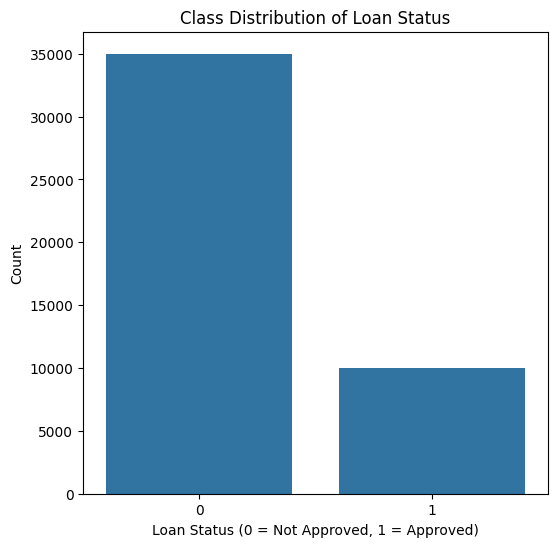

In [14]:
# TODO: Classification EDA
plt.figure(figsize=(6,6))
sns.countplot(x='loan_status', data=df1)
plt.title("Class Distribution of Loan Status")
plt.xlabel("Loan Status (0 = Not Approved, 1 = Approved)")
plt.ylabel("Count")
plt.show()

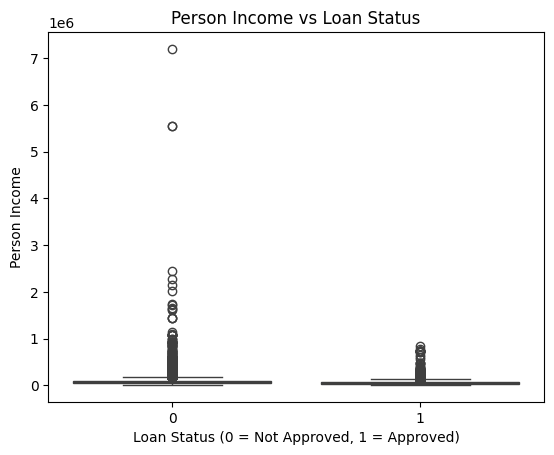

In [15]:
sns.boxplot(x='loan_status', y='person_income', data=df1)
plt.title("Person Income vs Loan Status")
plt.xlabel("Loan Status (0 = Not Approved, 1 = Approved)")
plt.ylabel("Person Income")
plt.show()


## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [16]:
# TODO: Prepare classification features

cat_features = ['person_gender', 'person_education', 'person_home_ownership',
                'loan_intent', 'previous_loan_defaults_on_file']
X_class = pd.get_dummies(df1.drop('loan_status', axis=1), columns=cat_features, drop_first=True, dtype=int)
y_class = df1['loan_status']

numeric_features = ['person_age', 'person_income', 'person_emp_exp',
                    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                    'cb_person_cred_hist_length', 'credit_score']

X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42, stratify=y_class)

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])


## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


In [17]:
# TODO: Logistic Regression
model = LogisticRegression(max_iter=100)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)

print("Logistic Regression (L2) Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion matrix: \n", cm)

Logistic Regression (L2) Metrics:
Accuracy: 0.8959
Precision: 0.7755
Recall: 0.7481

Confusion matrix: 
 [[6601  399]
 [ 506 1494]]


## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


In [18]:
# TODO: SVM Classification
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)


y_train_pred = svm_model.predict(X_train)
y_test_pred = svm_model.predict(X_test)

accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
recall_train = recall_score(y_train, y_train_pred)

print("SVM (Train) Metrics:")
print(f"Accuracy: {accuracy_train:.4f}")
print(f"Precision: {precision_train:.4f}")
print(f"Recall: {recall_train:.4f}")

cm = confusion_matrix(y_train, y_train_pred)
print("\nConfusion matrix (Train):\n", cm)

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)

print("\nSVM (Test) Metrics:")
print(f"Accuracy: {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")

cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion matrix (Test):\n", cm)

SVM (Train) Metrics:
Accuracy: 0.9234
Precision: 0.8674
Recall: 0.7734

Confusion matrix (Train):
 [[27054   946]
 [ 1813  6187]]

SVM (Test) Metrics:
Accuracy: 0.9180
Precision: 0.8541
Recall: 0.7610

Confusion matrix (Test):
 [[6740  260]
 [ 478 1522]]


## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant




Naive Bayes (Test) Metrics:
Accuracy: 0.7532
Precision: 0.4733
Recall: 0.9800

Confusion matrix (Test):
 [[4819 2181]
 [  40 1960]]


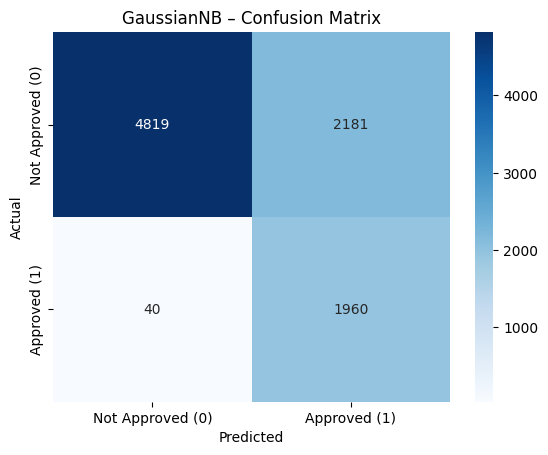

In [19]:
# TODO: Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_test_pred = nb_model.predict(X_test)

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)

print("\nNaive Bayes (Test) Metrics:")
print(f"Accuracy: {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")

cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion matrix (Test):\n", cm)

labels = ['Not Approved (0)', 'Approved (1)']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('GaussianNB – Confusion Matrix')
plt.show()


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      0.69      0.81      7000
           1       0.47      0.98      0.64      2000

    accuracy                           0.75      9000
   macro avg       0.73      0.83      0.73      9000
weighted avg       0.88      0.75      0.77      9000



## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


In [21]:
# TODO: KNN
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 21)
accs = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=2))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accs.append(acc)
print(accs)

[0.8756666666666667, 0.8793333333333333, 0.8888888888888888, 0.8886666666666667, 0.894, 0.8945555555555555, 0.8972222222222223, 0.8933333333333333, 0.8968888888888888, 0.8957777777777778, 0.8983333333333333, 0.8958888888888888, 0.8994444444444445, 0.8965555555555556, 0.8978888888888888, 0.8961111111111111, 0.8986666666666666, 0.8973333333333333, 0.8978888888888888, 0.8983333333333333]


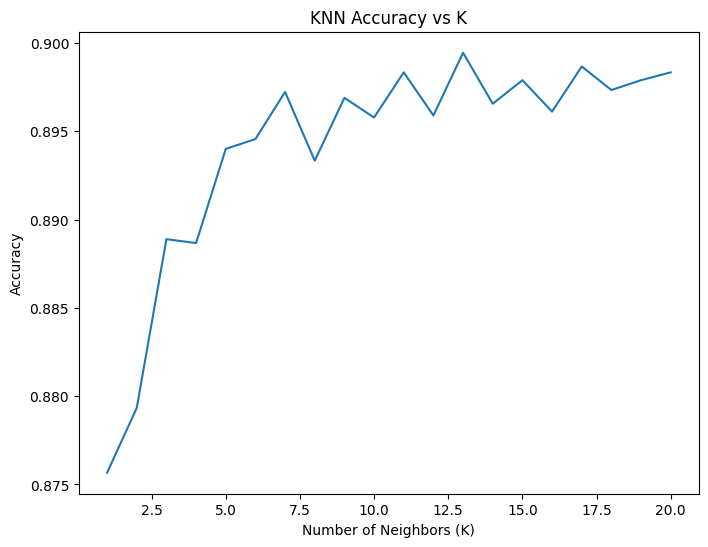

In [22]:
plt.figure(figsize=(8,6))
plt.plot(k_values, accs)
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.show()

In [23]:
best_k = list(k_values)[int(np.argmax(accs))]
print("Best K:", best_k)
print("Best Accuracy:", float(np.max(accs)))


Best K: 13
Best Accuracy: 0.8994444444444445


## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


In [24]:
# TODO: Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

rf_clf.fit(X_train, y_train)
y_pred = rf_clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9286666666666666
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96      7000
           1       0.90      0.77      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



In [25]:
importances = pd.Series(
    rf_clf.feature_importances_,
    index=X_class.columns
).sort_values(ascending=False)
importances

,0
previous_loan_defaults_on_file_Yes,0.218127
loan_percent_income,0.163793
loan_int_rate,0.157401
person_income,0.124549
loan_amnt,0.061482
person_home_ownership_RENT,0.056364
credit_score,0.054492
person_age,0.031961
person_emp_exp,0.028429
cb_person_cred_hist_length,0.026421


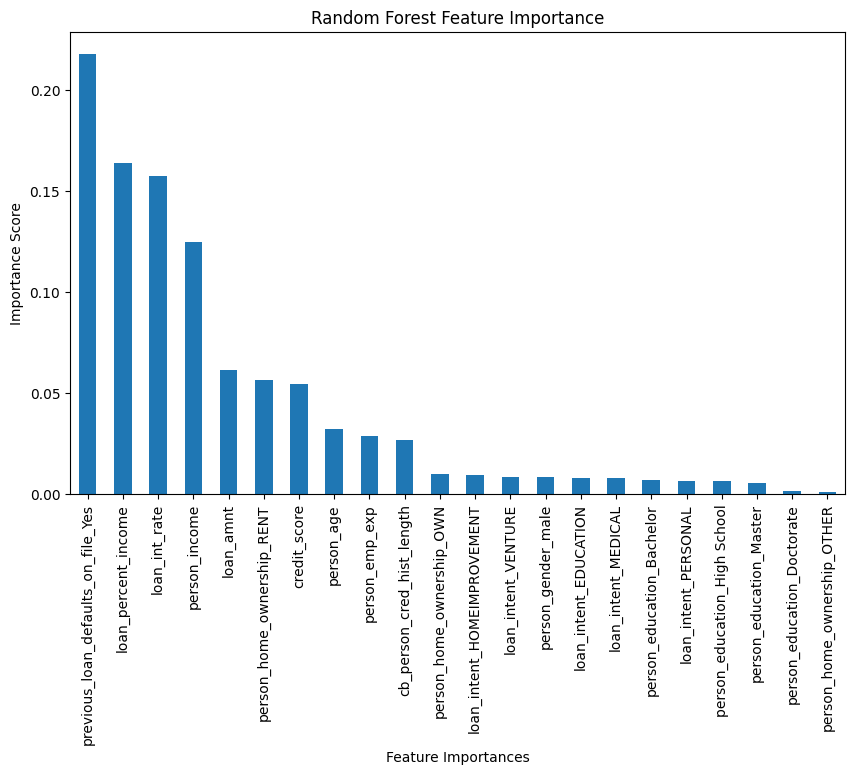

In [26]:
plt.figure(figsize=(10,6))
importances.plot(kind='bar')
plt.xlabel("Feature Importances")
plt.ylabel("Importance Score")
plt.title("Random Forest Feature Importance")
plt.show()

# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why

*The best regression model is Polynomial Regression because it captures the non-linear patterns in the data better than Linear Regression. On the test set, it achieved the highest R² (0.87) and the lowest RMSE (4551), indicating more accurate predictions. SVR performed very poorly, and although Random Forest is also good, close to Polynomial, but slightly higher error (RMSE).*

- Best classification model and why

*The best classification model is Random Forest because it achieved the highest accuracy (0.93) and a strong balance between precision and recall for both classes. While SVM also performed well, Random Forest slightly outperformed it overall and handles feature interactions automatically. Naive Bayes had high recall but very low precision, and KNN/Logistic were slightly lower in accuracy, making Random Forest the most reliable choice for predicting loan approval.*

- One real-world deployment scenario

*A retail e-commerce company could deploy these models to predict customer behavior and sales. Regression models can estimate how much a customer is likely to spend based on wishlists, browsing history, and past purchases. Classification models can predict whether a customer will make a purchase in a session or respond to a promotion. This helps the company personalize offers, optimize marketing campaigns, and increase sales.*

## TODO: Write your reflection here